In [1]:
#Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import seaborn as sns

#Load Dataset
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

#Data Cleaning
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [2]:
df_DA_In = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'India')].copy()

In [3]:
df_DA_In = df_DA_In.explode('job_skills')
df_DA_In_Top_Pay = df_DA_In.groupby('job_skills')['salary_year_avg'].agg(['count','median']).sort_values(by='median', ascending=False)
df_DA_In_Top_Pay = df_DA_In_Top_Pay.head(10)
df_DA_In_Popular = df_DA_In.groupby('job_skills')['salary_year_avg'].agg(['count','median']).sort_values(by='count', ascending=False)
df_DA_In_Popular = df_DA_In_Popular.head(10)

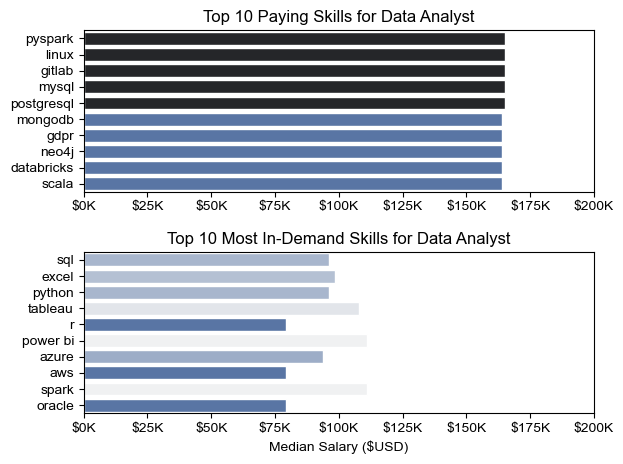

In [4]:
fig, ax = plt.subplots(2,1)

sns.set_theme(style='ticks')

# Top 10 Highest Paid skills for Data Analyst

sns.barplot(data=df_DA_In_Top_Pay, x='median', y=df_DA_In_Top_Pay.index, hue='median', ax=ax[0], palette='dark:b_r')
ax[0].legend().remove()
ax[0].set_title('Top 10 Paying Skills for Data Analyst')
ax[0].set_ylabel('')
ax[0].set_xlabel('')
ax[0].set_xlim(0,200000)
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'${int(x/1000)}K'))

fig.tight_layout()

# Top 10 Most Demanding Skills for Data Analyst

sns.barplot(data=df_DA_In_Popular, x='median', y=df_DA_In_Popular.index, hue='median', ax=ax[1], palette='light:b_r')
ax[1].legend().remove()
ax[1].set_title('Top 10 Most In-Demand Skills for Data Analyst')
ax[1].set_ylabel('')
ax[1].set_xlabel('Median Salary ($USD)')
ax[1].set_xlim(0,200000)
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'${int(x/1000)}K'))
fig.tight_layout()